# TPCQ-Net — Commuting-Generator Training
**Parallel gradient (Bowles et al. 2025) — commuting X-generator global circuit**

Reference:
> *Backpropagation scaling in parameterised quantum circuits*  
> Bowles, Wierichs, Park. Quantum 9, 1873 (2025). arXiv:2306.14962

**Key difference from baseline:**  
The global circuit uses mutually commuting X-product generators.  
All gradients are estimated from **N_QUBITS circuits per sample** instead of `2 × n_gate_params`.

Run this notebook AFTER `01_baseline_training.ipynb`.  
Results saved to `results/commuting/` for comparison in notebook 03.

In [1]:
import os, sys, math, time, json
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

sys.path.insert(0, '.')
from qc_circuits import build_local_circuit, build_global_circuit_commuting, build_commuting_gen_classes
from qc_runner import setup_commuting
from qc_model import build_commuting_model
from qc_train import (train_model, evaluate, make_loaders,
                       compute_circuit_counts, print_circuit_counts,
                       _stratified_indices)
from qc_logs import compute_analysis, print_analysis
from parallel_gradient import ParallelGradientEngine

torch.manual_seed(42)
np.random.seed(42)
os.makedirs('results/commuting', exist_ok=True)
print('Imports OK')


C:\Users\Mominul\anaconda3\envs\qml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## Configuration

`DATASET_MODE`, `TRAIN_SAMPLES`, `VAL_SAMPLES`, `BATCH_SIZE`, `EPOCHS`, and `LR`  
**must match notebook 01 exactly** for a fair comparison.

In [2]:
class CFG:
    # ── quantum architecture (must match baseline) ─────────────────────
    N_QUBITS          = 3
    N_Q_LAYERS        = 3
    N_Q_LAYERS_GLOBAL = 6        # kept for analysis/compat
    N_MEASURE_BASES   = 3
    MAX_WEIGHT        = 2        # max Pauli weight of commuting X-generators

    # ── feature map (must match baseline) ─────────────────────────────
    Q_RES    = 5
    Q_STRIDE = 3

    # ── Aer (must match baseline) ─────────────────────────────────────
    AER_METHOD = 'statevector'
    AER_SHOTS  = None

    # ── dataset (must match baseline) ─────────────────────────────────
    DATASET_MODE  = 'subset'
    TRAIN_SAMPLES = 2500
    VAL_SAMPLES   = 200

    # ── training (must match baseline) ────────────────────────────────
    BATCH_SIZE = 16
    EPOCHS     = 3
    LR         = 1e-3

    # ── output paths ──────────────────────────────────────────────────
    CSV_PATH   = 'results/commuting/training_log.csv'
    MODEL_PATH = 'results/commuting/model_best.pth'

    @classmethod
    def n_inputs(cls):
        return cls.N_QUBITS * cls.Q_RES * cls.Q_RES

    @classmethod
    def inputs_per_layer(cls):
        return math.ceil(cls.n_inputs() / cls.N_Q_LAYERS_GLOBAL)

    @classmethod
    def q_out(cls):
        return cls.N_QUBITS * cls.N_MEASURE_BASES


# ── show generator structure ──────────────────────────────────────────────
gen_classes = build_commuting_gen_classes(CFG.N_QUBITS, CFG.MAX_WEIGHT)
n_logical   = len(gen_classes)
n_gates     = sum(len(cls) for cls in gen_classes)

print(f"Dataset mode          : {CFG.DATASET_MODE}")
print(f"Commuting generators  (max_weight={CFG.MAX_WEIGHT}):")
for i, cls in enumerate(gen_classes):
    print(f"  θ_{i}: {[(w, wires) for w, wires in cls]}")
print()
print(f"Logical params        : {n_logical}")
print(f"Gate params (circuit) : {n_gates}")
print(f"Backward (parallel)   : {CFG.N_QUBITS} circuits/sample")
print(f"Backward (param-shift): {2*n_gates} circuits/sample  [baseline reference]")
print(f"Speedup               : {2*n_gates / CFG.N_QUBITS:.1f}×")


Dataset mode          : subset
Commuting generators  (max_weight=2):
  θ_0: [('X', [2]), ('X', [1]), ('X', [0])]
  θ_1: [('XX', [1, 2]), ('XX', [0, 1]), ('XX', [0, 2])]

Logical params        : 2
Gate params (circuit) : 6
Backward (parallel)   : 3 circuits/sample
Backward (param-shift): 12 circuits/sample  [baseline reference]
Speedup               : 4.0×


## Verify parallel gradient matches param-shift

This is the correctness check before training.  
Max error should be ≲ 1e-8.

In [3]:
from qiskit.quantum_info import SparsePauliOp, Statevector

qc_t, x_t, w_t, gc_t, gtc_t = build_global_circuit_commuting(
    CFG.N_QUBITS, CFG.n_inputs(), CFG.MAX_WEIGHT
)
engine_t = ParallelGradientEngine(gc_t, gtc_t, CFG.N_QUBITS)
s        = engine_t.speedup_vs_param_shift()
print(engine_t)

x_v = np.random.uniform(0, np.pi, CFG.n_inputs())
w_v = np.random.uniform(0, 2*np.pi, s['n_gate_params'])

H_op = SparsePauliOp.from_list(
    [('I'*(CFG.N_QUBITS-1-r)+'Z'+'I'*r, 1/CFG.N_QUBITS) for r in range(CFG.N_QUBITS)]
)

def cost_t(wv):
    b = qc_t.assign_parameters({**dict(zip(x_t, x_v)), **dict(zip(w_t, wv))})
    return Statevector(b).expectation_value(H_op).real

# param-shift per gate, aggregate to logical
g_ps = np.zeros(s['n_logical_params'])
for k in range(s['n_gate_params']):
    p, m = w_v.copy(), w_v.copy()
    p[k] += np.pi/2;  m[k] -= np.pi/2
    g_ps[gtc_t[k]] += (cost_t(p) - cost_t(m)) / 2

# parallel gradient
b2  = qc_t.assign_parameters({**dict(zip(x_t, x_v)), **dict(zip(w_t, w_v))})
psi = Statevector(b2).data
g_par = engine_t.gradient_exact(psi)

print(f'Param-shift : {np.round(g_ps,  6)}')
print(f'Parallel    : {np.round(g_par, 6)}')
print(f'Match       : {np.allclose(g_ps, g_par, atol=1e-8)}')
print(f'Max error   : {np.max(np.abs(g_ps - g_par)):.2e}')


ParallelGradientEngine(n_logical=2, n_gates=6, param_shift_circuits=12, parallel_circuits=3, speedup=4.0x)
Param-shift : [-0.271555  0.345032]
Parallel    : [-0.271555  0.345032]
Match       : True
Max error   : 1.28e-15


## Data

In [4]:
train_loader, val_loader, n_train, n_val = make_loaders(CFG)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:05<00:00, 1.95MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 101kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.00MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:01<00:00, 2.63kB/s]


Dataset mode : SUBSET
Train        : 2500 samples  (157 batches)
Val          : 200   samples  (13 batches)


## Build circuits and runner

In [5]:
runner_ctx = setup_commuting(CFG)
print(f'Runner variant  : {runner_ctx.variant}')
print(f'Gate params     : {runner_ctx.n_gate_params_g}')
print(f'Logical params  : {runner_ctx.n_logical_params_g}')


[Commuting] Local  depth: 15  weights: 9
[Commuting] Global depth: 37
[Commuting] ParallelGradientEngine(n_logical=2, n_gates=6, param_shift_circuits=12, parallel_circuits=3, speedup=4.0x)
[Commuting] Backward cost per sample: 18 local + 3 global (vs 12 param-shift)
Runner variant  : commuting
Gate params     : 6
Logical params  : 2


## Circuit analysis

In [6]:
analysis = compute_analysis(CFG, runner_ctx)
print_analysis(analysis, 'Commuting-Generator')

counts = compute_circuit_counts(CFG, runner_ctx, n_train)
print_circuit_counts(counts, 'Commuting-Generator')


══════════════════════════════════════════════════════════════════════
                TPCQ-Net Analysis — Commuting-Generator               
══════════════════════════════════════════════════════════════════════
  Variant                             commuting
  Qubits                              3
  Local weight params                 9
  Global gate params                  6
  Global logical params               2
  Classical total params              29,837
  Quantum total params                15
  Model total params                  29,852
──────────────────────────────────────────────────────────────────────
  Backward method (global)            parallel: 3 circuits/sample (+ 8/sample for X,Y)
  Total forward circuits              48,600
  Total backward circuits             487,500
  Grand total circuits                536,100
  Backward / forward ratio            10.0x
══════════════════════════════════════════════════════════════════════

  Circuit execution budget — Commutin

## Circuit visualisation

=== LOCAL CIRCUIT (unchanged) ===


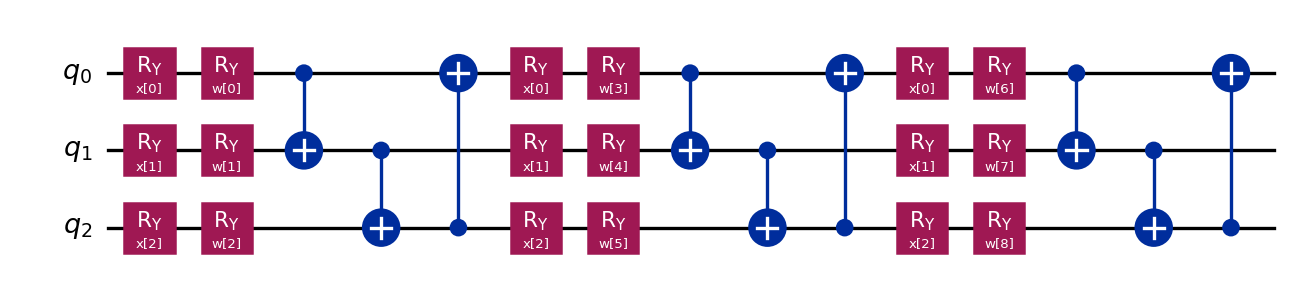

=== GLOBAL CIRCUIT (commuting X-generators) ===


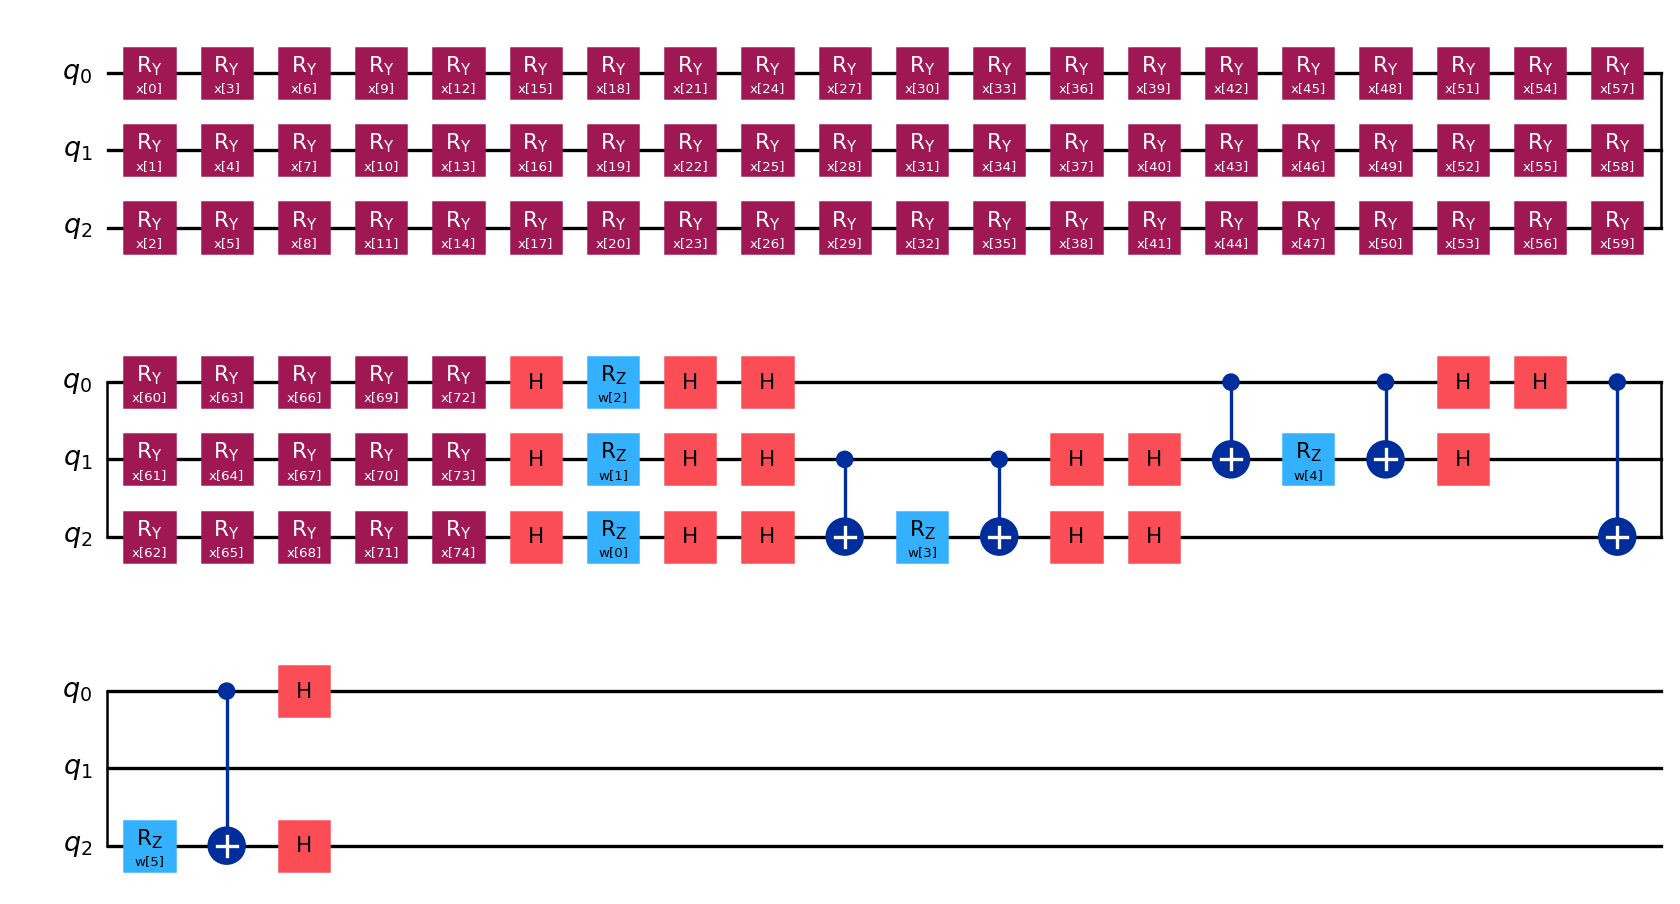

In [7]:
from IPython.display import display
qc_l, x_l, w_l = build_local_circuit(CFG.N_QUBITS, CFG.N_Q_LAYERS)
qc_g, x_g, w_g, gc, gtc = build_global_circuit_commuting(
    CFG.N_QUBITS, CFG.n_inputs(), CFG.MAX_WEIGHT
)
print('=== LOCAL CIRCUIT (unchanged) ===')
display(qc_l.draw(output='mpl', style='iqp', fold=60))
print('=== GLOBAL CIRCUIT (commuting X-generators) ===')
display(qc_g.draw(output='mpl', style='iqp', fold=20))


## Build model

In [8]:
model = build_commuting_model(CFG, runner_ctx)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total:,}')


[Commuting model] Total params: 29,372  (quantum: 15, 0.05%)
  Global circuit: 6 gate params, 2 logical params
Total trainable parameters: 29,372


## Smoke test

In [9]:
model.eval()
x_s, y_s = next(iter(val_loader))
with torch.no_grad():
    out = model(x_s[:2])
print(f'Forward pass OK — output shape: {out.shape}')
print(f'Logits sample: {out[0].detach().numpy().round(4)}')


Forward pass OK — output shape: torch.Size([2, 10])
Logits sample: [-0.1657 -0.0393 -0.1791  0.0627 -0.126   0.0692 -0.1584 -0.011   0.0424
 -0.0734]


## Train

The progress bar shows batch loss and running accuracy.  
Each epoch's backward pass uses **3 Aer circuits** instead of 12 (param-shift).

In [10]:
t_start = time.time()

results = train_model(
    model           = model,
    cfg             = CFG,
    runner_ctx      = runner_ctx,
    train_loader    = train_loader,
    val_loader      = val_loader,
    tag             = 'Commuting',
    save_path       = CFG.MODEL_PATH,
    csv_path        = CFG.CSV_PATH,
    n_train_samples = n_train,
    n_val_samples   = n_val,
)

wall_time = time.time() - t_start
print(f'\nTotal wall-clock time: {wall_time:.1f}s  ({wall_time/60:.1f} min)')



  Circuit execution budget — Commuting
  Forward  (train):        22,500  local
                           22,500  global
  Forward  (val):           1,800  local
                            1,800  global
  Backward (train):       405,000  local
                           82,500  global
  ─────────────────────────────────────────────
  Forward total:           48,600
  Backward total:         487,500
  Grand total:            536,100
  Bwd / Fwd ratio:          10.0×


[Commuting] Epoch  1/3: 100%|██████████████████████████████████████████████████████████████████| 157/157 [05:34<00:00,  2.13s/batch, acc=0.133, loss=2.2816]


  └─ loss=2.2816  train_acc=0.133  val_acc=0.2150  top5=0.7750  val_t=2.2s  total_t=337.1s ✓ saved


[Commuting] Epoch  2/3: 100%|██████████████████████████████████████████████████████████████████| 157/157 [05:26<00:00,  2.08s/batch, acc=0.252, loss=1.9753]


  └─ loss=1.9753  train_acc=0.252  val_acc=0.2500  top5=0.9000  val_t=2.2s  total_t=328.9s ✓ saved


[Commuting] Epoch  3/3: 100%|██████████████████████████████████████████████████████████████████| 157/157 [05:28<00:00,  2.09s/batch, acc=0.413, loss=1.5842]


  └─ loss=1.5842  train_acc=0.413  val_acc=0.5400  top5=0.9400  val_t=2.2s  total_t=331.2s ✓ saved

[Commuting] Training complete. Best val acc: 0.5400  |  Log: results/commuting/training_log.csv

Total wall-clock time: 997.1s  (16.6 min)


## Training curves

 epoch  train_loss  val_acc  val_top5  epoch_time_s
     1    2.281600    0.215     0.775        337.05
     2    1.975311    0.250     0.900        328.86
     3    1.584180    0.540     0.940        331.19


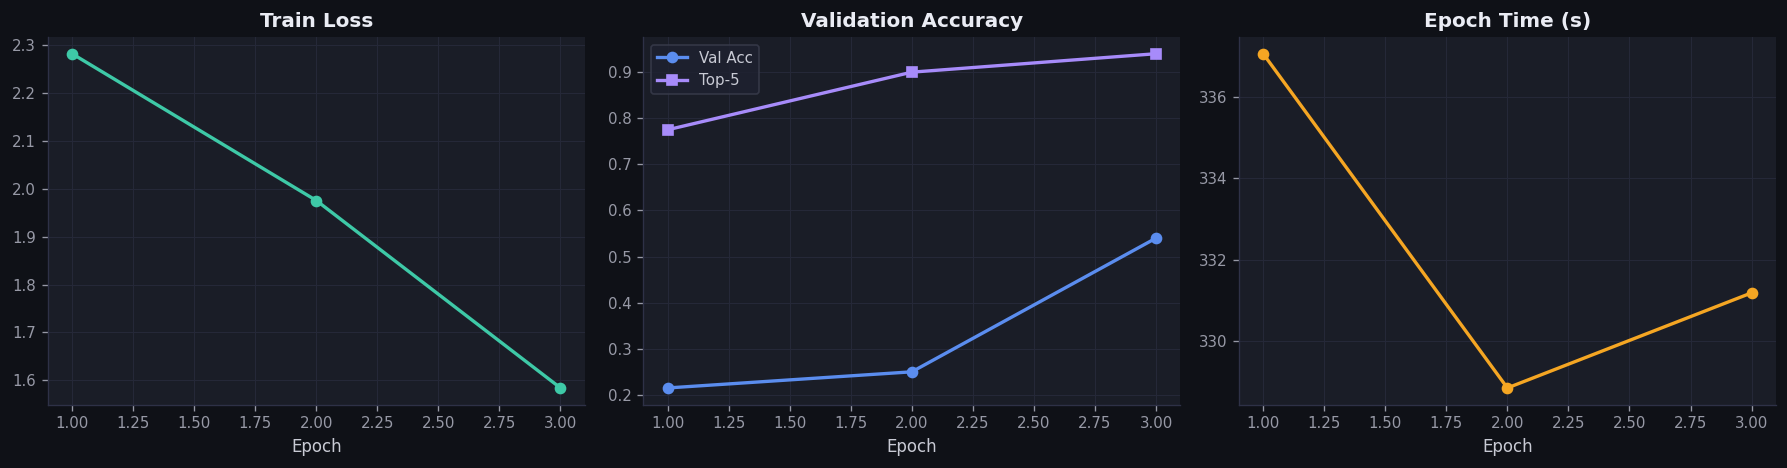

Saved results/commuting/training_curves.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(CFG.CSV_PATH)
print(df[['epoch','train_loss','val_acc','val_top5','epoch_time_s']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df['epoch'], df['train_loss'], color='#3EC9A7', marker='o', linewidth=2)
axes[0].set_title('Train Loss', fontweight='bold'); axes[0].set_xlabel('Epoch')

axes[1].plot(df['epoch'], df['val_acc'],  color='#5B8DEF', marker='o', linewidth=2, label='Val Acc')
axes[1].plot(df['epoch'], df['val_top5'], color='#A78BFA', marker='s', linewidth=2, label='Top-5')
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(df['epoch'], df['epoch_time_s'], color='#F5A623', marker='o', linewidth=2)
axes[2].set_title('Epoch Time (s)', fontweight='bold'); axes[2].set_xlabel('Epoch')

for ax in axes: ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/commuting/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved results/commuting/training_curves.png')


## Save summary

In [12]:
summary = {
    'variant':            'commuting',
    'best_acc':           results['best_acc'],
    'circuit_counts':     results['circuit_counts'],
    'wall_time_s':        wall_time,
    'epochs':             CFG.EPOCHS,
    'dataset_mode':       CFG.DATASET_MODE,
    'train_samples':      results['n_train'],
    'val_samples':        results['n_val'],
    'n_qubits':           CFG.N_QUBITS,
    'max_weight':         CFG.MAX_WEIGHT,
    'n_gate_params_g':    runner_ctx.n_gate_params_g,
    'n_logical_params_g': runner_ctx.n_logical_params_g,
}
with open('results/commuting/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved results/commuting/summary.json')
print(f"Best val accuracy  : {results['best_acc']:.4f}")
print(f"Grand total circs  : {results['circuit_counts']['grand_total']:,}")
print(f"Global bwd circs   : {results['circuit_counts']['global_bwd']:,}")


Saved results/commuting/summary.json
Best val accuracy  : 0.5400
Grand total circs  : 536,100
Global bwd circs   : 82,500
